In [53]:
# imports
suppressPackageStartupMessages({
    library(data.table)
    library(Matrix)
    library(Seurat)
    library(ggplot2)
    library(dplyr)
    library(ggthemes)
    library(tidyr)
    library(tibble)
})

source('../_common/typing_utils.r')

Loading required package: Rcpp


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [6]:
samples = 'EDP1-EDP2-ARB'

# QC cells

In [24]:
seu <- readRDS(file = paste0("../../data/early_disease_synovium/xenium/combined/", samples, "/allcells.rds"))

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



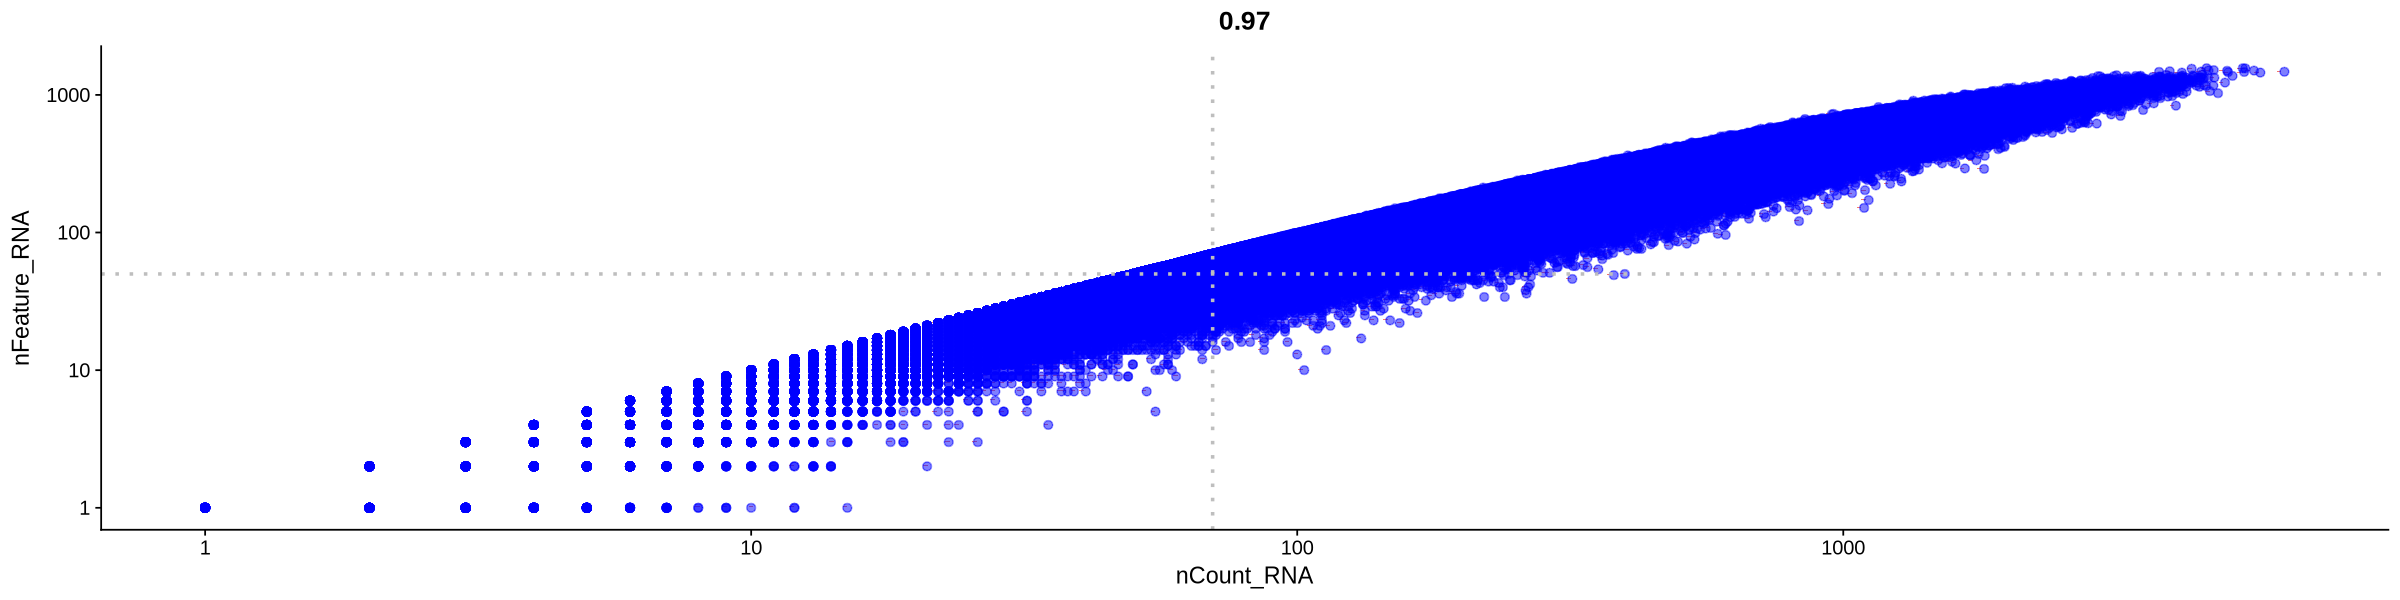

In [26]:
# Create the scatter plot
plot <- FeatureScatter(object = seu, 
                       feature1 = "nCount_RNA", 
                       feature2 = "nFeature_RNA") +
        geom_point(size = 2, color = "blue", alpha = 0.5)

# Add the dotted vertical and horizontal lines
plot <- plot + 
  geom_vline(xintercept = 70, linetype = "dotted", color = "gray", linewidth = 1) +
  geom_hline(yintercept = 50, linetype = "dotted", color = "gray", linewidth = 1) +
  scale_x_log10() + 
  scale_y_log10() +

print(plot)

In [27]:
# Filter out low-quality cells
seu_qc <- subset(seu, subset = nCount_RNA >= 70 & nFeature_RNA >= 50 & avg_assignment_confidence >= 0.5)
cat("Original #cells:", ncol(seu), "\n")
cat("Filtered #cells:", ncol(seu_qc), "\n")

Original cells: 12548652 
Filtered cells: 5151385 


In [36]:
# Filter out samples with very few cells
valid_sids <- seu_qc@meta.data %>%
    count(sid) %>%
    filter(n >= 500) %>%
    pull(sid)

cat("Original #cells:", ncol(seu_qc), "\n")
cat("Original #samples:", length(unique(seu_qc@meta.data$sid)), "\n")
seu_qc <- subset(seu_qc, subset = sid %in% valid_sids)
cat("Filtered #cells:", ncol(seu_qc), "\n")
cat("Original #samples:", length(unique(seu_qc@meta.data$sid)), "\n")

Original #cells: 5151385 
Original #samples: 102 
Filtered #cells: 5150888 
Original #samples: 100 


In [28]:
# Convert gene names from Xenium to AMPp2 
gene_aliases <- list(
  "ATPSCKMT" = "FAM173B", "CCN1" = "CYR61", "CCN2" = "CTGF", "CCN3" = "NOV", "CCN4" = "WISP1", "CCN5" = "WISP2",
  "ECRG4" = "C2orf40", "EEF1AKNMT" = "METTL13", "ITPRID2" = "SSFA2", "LRATD2" = "FAM84B",
  "MRTFA" = "MKL1", "MRTFB" = "MKL2", "MTRES1" = "C6orf203", "NIBAN1" = "FAM129A", "NOTCH2NLA" = "NOTCH2NL",
  "PACC1" = "TMEM206", "POGLUT2" = "KDELC1", "PRXL2A" = "FAM213A", "PWWP3A" = "MUM1", "RO60" = "TROVE2",
  "SEPTIN5" = "SEPT5", "SEPTIN6" = "SEPT6", "SEPTIN9" = "SEPT9", "SHFL" = "C19orf66",
  "TAFA5" = "FAM19A5", "TASOR" = "FAM208A", "TASOR2" = "FAM208B"
)

current_genes <- rownames(seu_qc[['RNA']])
new_genes <- sapply(current_genes, function(g) {
  if (g %in% names(gene_aliases)) gene_aliases[[g]] else g
})
rownames(seu_qc[['RNA']]) <- new_genes

In [37]:
# save
saveRDS(seu_qc, file=paste0('out_rds/',samples,'/allcells_qc.rds'))

## Compare resulting transcript counts across samples

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


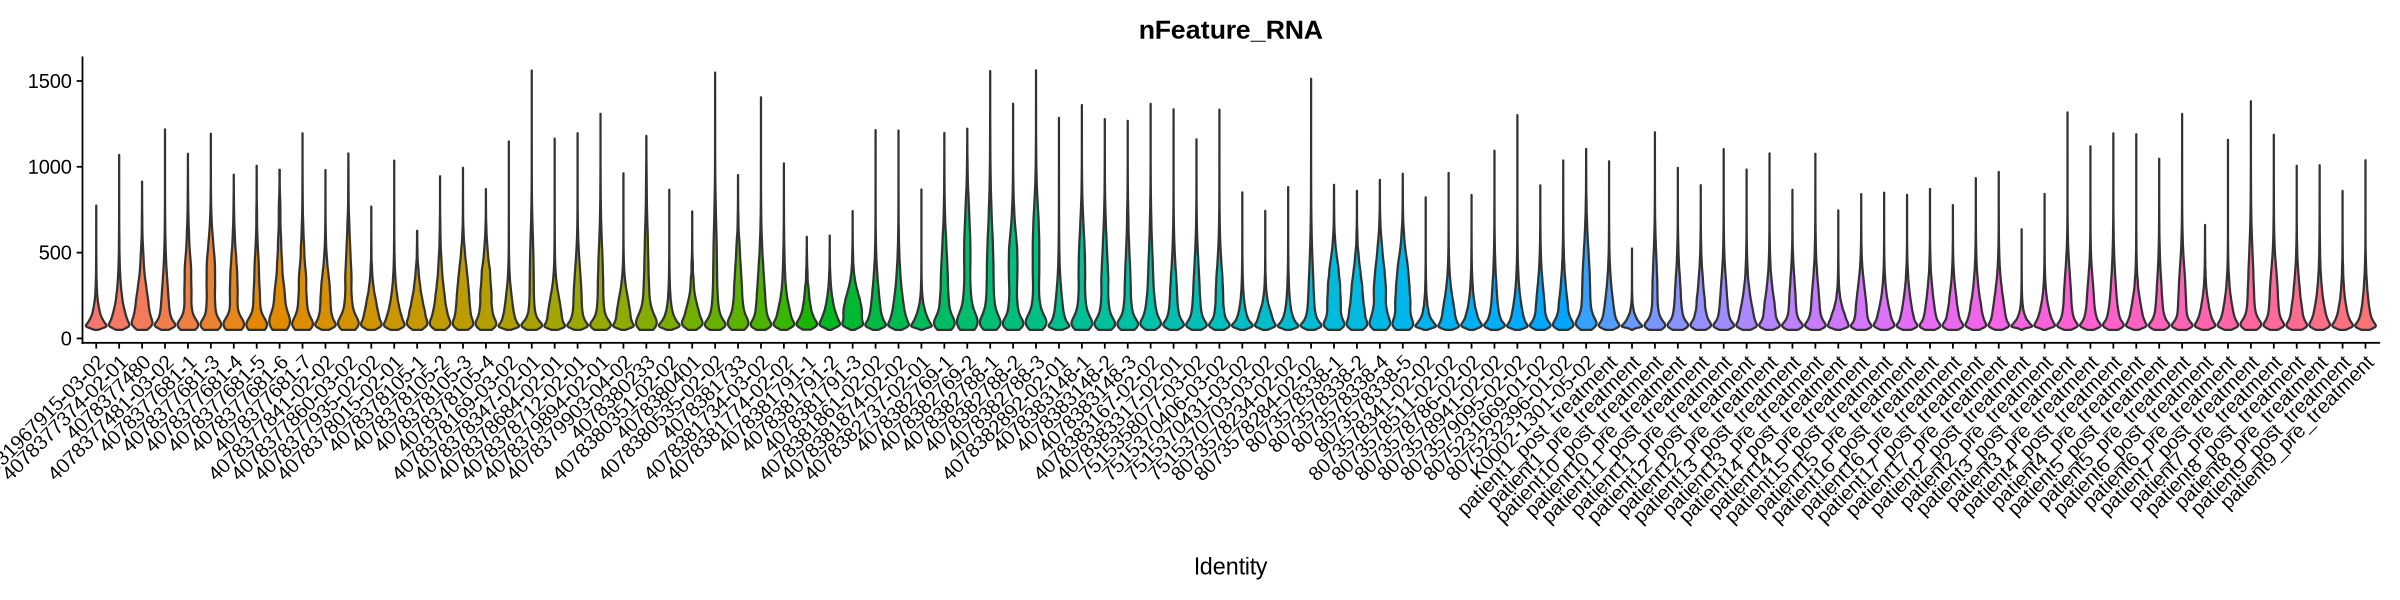

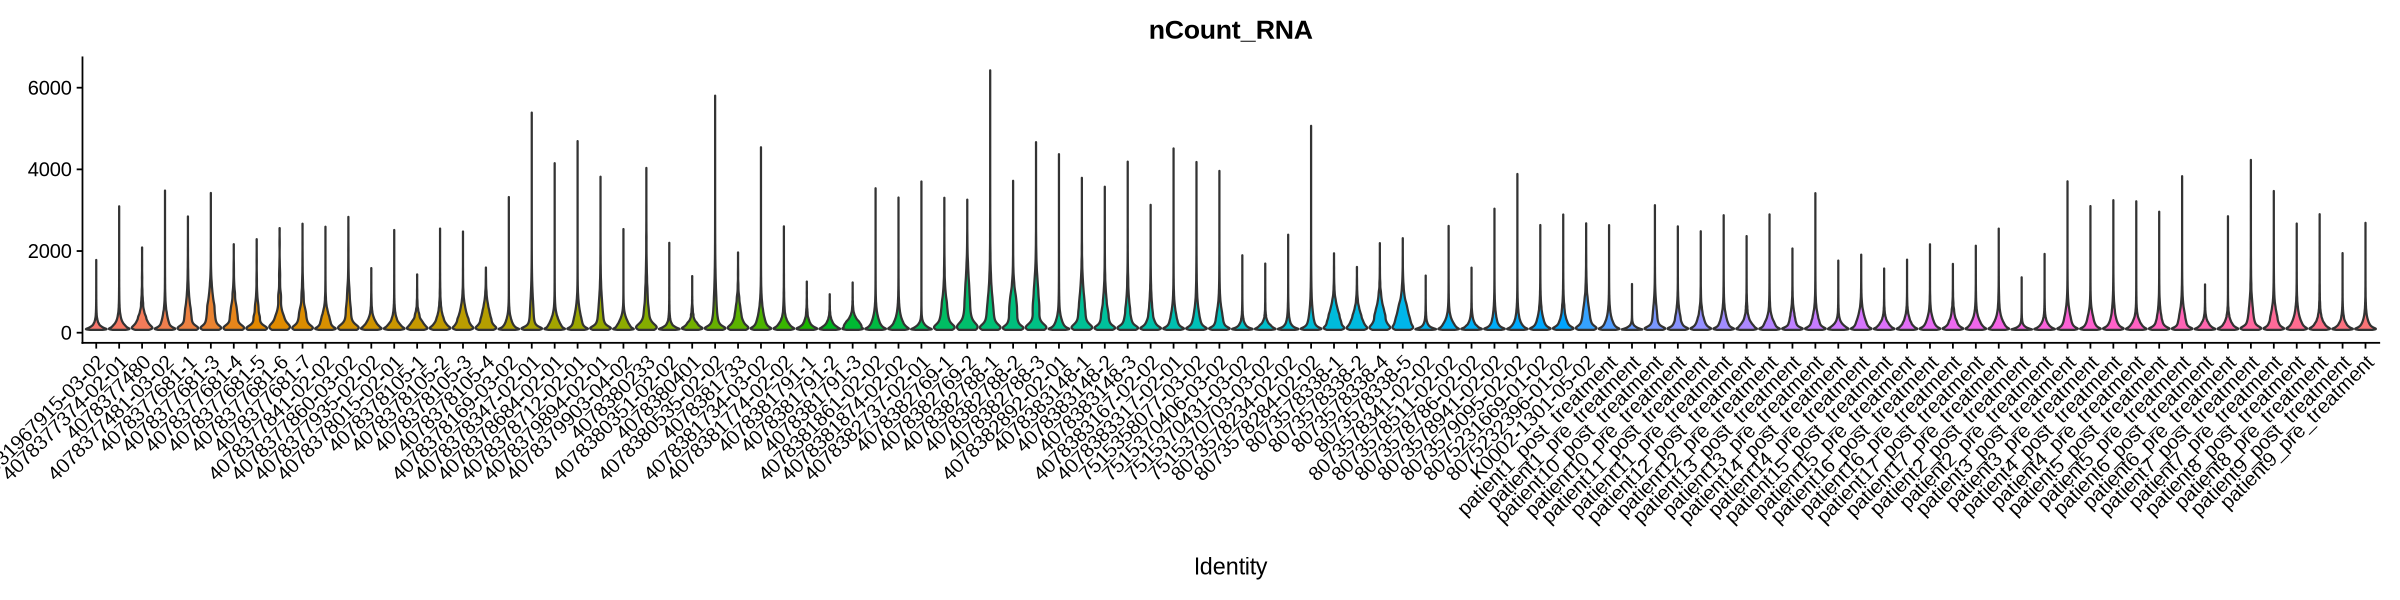

In [38]:
fig.size(5,20)
VlnPlot(seu_qc, features = "nFeature_RNA", group.by = "sid", pt.size = 0) + NoLegend()
VlnPlot(seu_qc, features = "nCount_RNA", group.by = "sid", pt.size = 0) + NoLegend()

# Save and visualize downsampled version (for sanity checks/prototyping)

In [39]:
# read in all cells and downsample for quicker testing - this should be commented out when running the full pipeline
seu_qc_sm = subset(seu_qc, cells = sample(colnames(seu_qc), 200000))
saveRDS(seu_qc_sm, file=paste0('out_rds/',samples,'/allcells_qc_downsampled.rds'))

In [41]:
seu_qc_sm <- seu_qc_sm %>% 
            NormalizeData(normalization.method = "LogNormalize", scale.factor = median(seu_qc_sm$nCount_RNA), verbose = F) %>% 
            FindVariableFeatures(selection.method = "vst", nfeatures = 2000) %>%
            ScaleData()

Finding variable features for layer counts

Centering and scaling data matrix



In [42]:
set.seed(0)
seu_qc_sm <- RunPCA(seu_qc_sm, verbose = T)

PC_ 1 
Positive:  C1QC, CTSS, C1QA, CD14, SLCO2B1, STAB1, LGMN, HLA-DQA1, CD163, CYBB 
	   MARCO, MSR1, SIGLEC1, CD4, ITGB2, FCGR2A, TYROBP, NCF1, VSIG4, CD68 
	   CSF1R, GRN, F13A1, CTSL, CYBA, MRC1, AP1B1, ARRB2, IL10RA, FCGR2B 
Negative:  TIMP3, TNXB, CLU, HSPG2, FSTL1, COL4A1, TNC, COL5A1, COL4A2, ANGPTL2 
	   PRSS23, ABI3BP, COL18A1, PRG4, MRC2, PDGFRB, COL5A2, CTGF, THY1, CFH 
	   EPAS1, VWF, CRTAC1, NID1, ACTA2, CD34, SERPINH1, ACKR3, CXCL12, AEBP1 
PC_ 2 
Positive:  PRG4, CLU, CRTAC1, HTRA1, TNXB, ABI3BP, MRC2, FSTL1, COLEC12, SEMA3C 
	   ERRFI1, TIMP3, ANGPTL2, GPNMB, WISP2, TNC, VCAM1, PDGFRA, C1QC, ACKR3 
	   C1QA, ANPEP, GPR1, PLTP, CD68, MMP3, COL5A2, MARCO, CFB, CYP1B1 
Negative:  VWF, PECAM1, PLVAP, SHANK3, TIE1, CCL14, SOX18, FLT1, ITGB4, CD34 
	   MZB1, CDH5, MMRN2, EGFL7, TENT5C, CLEC14A, EPAS1, PIM2, PODXL, POU2AF1 
	   BCAM, DERL3, CD79A, XBP1, CLDN5, ROBO4, ADGRL4, CD3E, KDR, CD93 
PC_ 3 
Positive:  MZB1, XBP1, TENT5C, SDC1, PIM2, POU2AF1, DERL3, CD79A, SLAMF7, FCR

In [48]:
seu_qc_sm <- Run_uwot_umap(seu_qc_sm, spread = 0.8, min_dist = 0.3, reduction="pca")

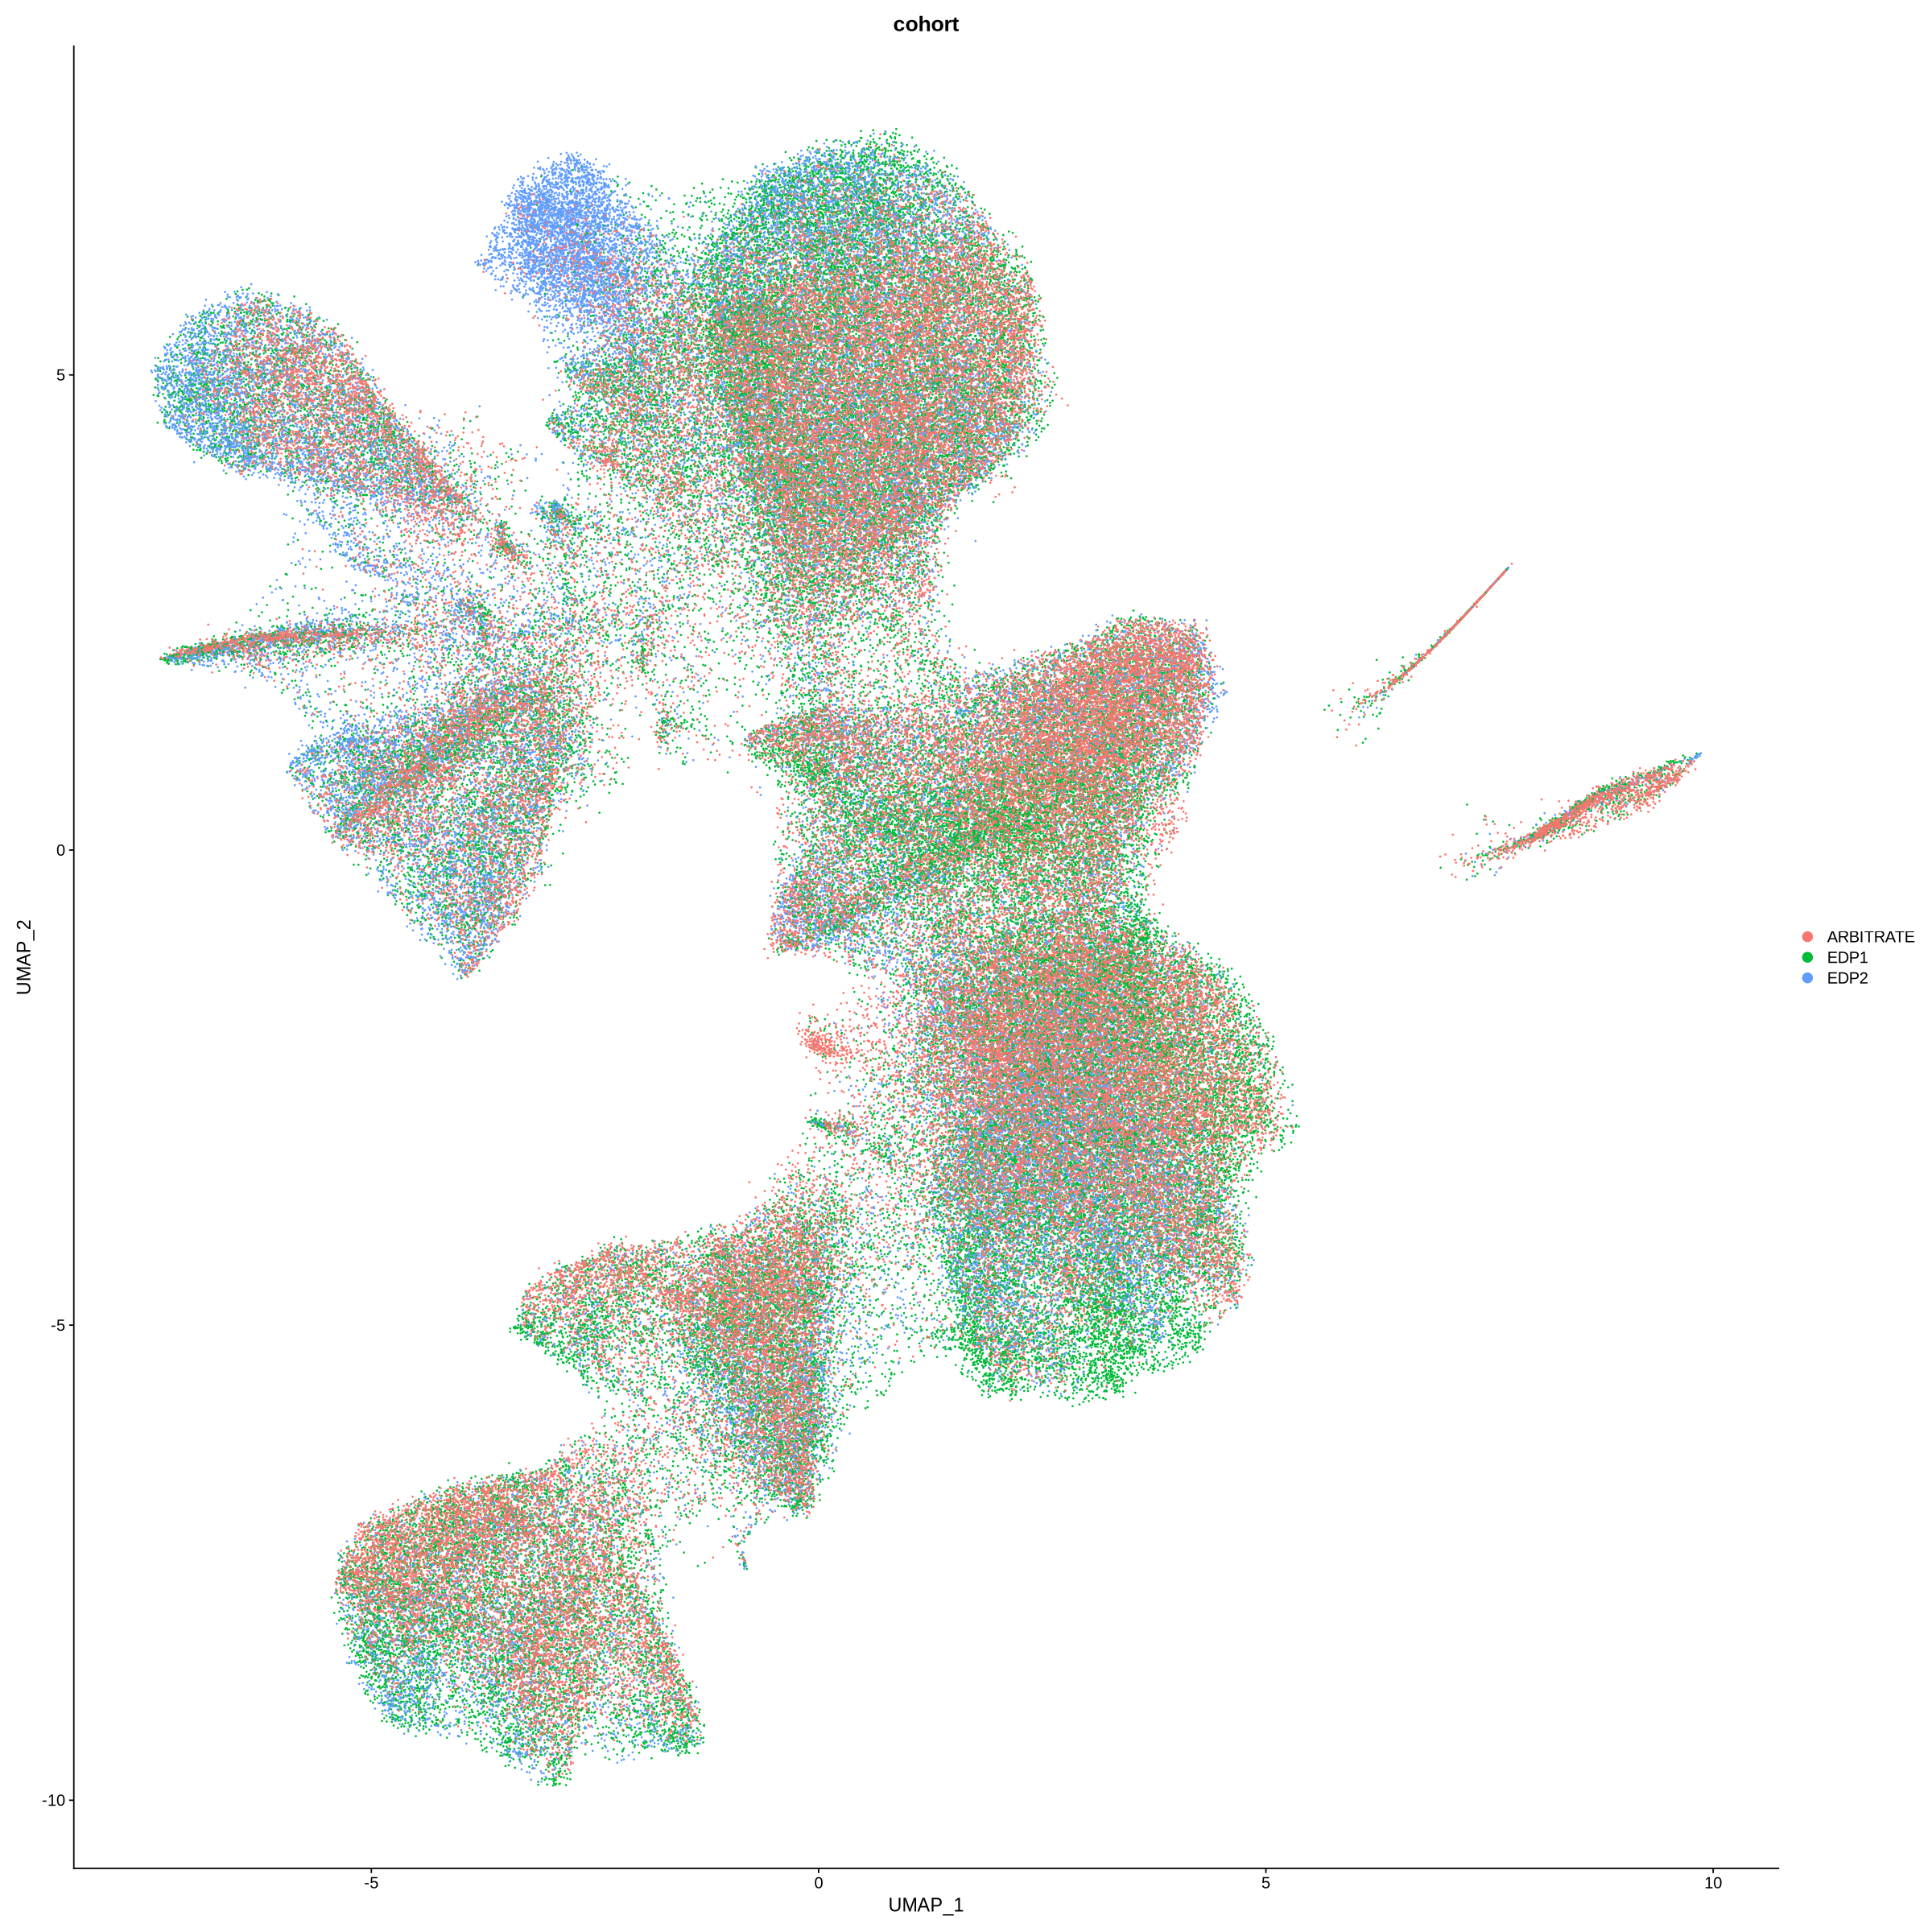

In [52]:
fig.size(20,20)
DimPlot(seu_qc_sm,  group.by = "cohort", raster = F)